In [11]:
import os
from pathlib import Path
import sys
ROOT = ".." # Base directory relative to this notebook's location. Adjust if the notebook is moved
sys.path.append(ROOT)
CSV_DIR = os.path.join(ROOT, "csv")
STATS_DIR = os.path.join(CSV_DIR, "stats")
HIST_DATA_DIR = os.path.join(CSV_DIR, "historical-data")
JSON_DIR = os.path.join(ROOT, "json")
MAPS_DIR = os.path.join(ROOT, "maps")
GEO_DATA_PATH = os.path.join(JSON_DIR, "location-metadata.json")
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import geopandas as gpd
import contextily as ctx
from IPython.display import clear_output
import time
from src.station_time_series import create_station_time_series

## Create a station-wide time series

### Creating the file

In [10]:
GLOBAL_TIME_SERIES_PATH = os.path.join(STATS_DIR, "tmin_by_station.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARS"]
tmin_by_station = create_station_time_series(
    source_path=HIST_DATA_DIR,
    export_path=GLOBAL_TIME_SERIES_PATH,
    metric="tmin",
    provinces_to_exclude=None,
    provinces_to_include=None,
    max_interpolation_days=10,
)
tmin_by_station.head()

0009X_hist.csv: 3946 records processed
0016A_hist.csv: 4142 records processed
0034X_hist.csv: 4142 records processed
0042Y_hist.csv: 4125 records processed
0061X_hist.csv: 3993 records processed
0066X_hist.csv: 4138 records processed
0073X_hist.csv: 3896 records processed
0076_hist.csv: 4143 records processed
0092X_hist.csv: 4096 records processed
0106X_hist.csv: 4105 records processed
0114X_hist.csv: 4142 records processed
0120X_hist.csv: 4127 records processed
0149X_hist.csv: 4097 records processed
0158X_hist.csv: 4139 records processed
0171X_hist.csv: 3765 records processed
0194D_hist.csv: 4057 records processed
0201X_hist.csv: 3945 records processed
0222X_hist.csv: 4143 records processed
0244X_hist.csv: 4077 records processed
0260X_hist.csv: 4082 records processed
0281Y_hist.csv: 4138 records processed
0284X_hist.csv: 4107 records processed
0312X_hist.csv: 4121 records processed
0320I_hist.csv: 4094 records processed
0360X_hist.csv: 4101 records processed
0363X_hist.csv: 4128 recor

,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,C669B,C689E,C839X,C916Q,C917E,C919K,C925F,C928I,C929I,C939T
fecha,,,,,,,,,,,,,,,,,,,,,
2015-01-01,2.4,-1.1,-0.1,4.6,-1.2,-0.1,3.9,2.9,-1.9,-5.7,...,15.5,16.7,NaN,9.8,10.6,17.4,8.30,NaN,18.9,16.6
2015-01-02,6.1,-1.4,-1.2,4.5,-0.8,-1.5,4.0,3.1,0.0,-4.8,...,14.9,16.7,NaN,9.0,10.4,17.1,7.40,NaN,18.5,16.9
2015-01-03,8.6,-1.1,6.3,6.3,7.7,-0.2,5.0,6.1,2.0,-3.1,...,13.8,15.9,NaN,8.3,9.7,16.5,6.65,NaN,17.8,15.7
2015-01-04,7.6,0.5,4.1,6.3,2.7,2.1,7.2,6.1,1.6,-2.8,...,14.0,16.2,NaN,7.6,9.1,15.8,5.90,NaN,17.0,14.8
2015-01-05,3.7,2.2,1.0,6.7,1.2,1.0,6.2,4.9,0.8,-3.8,...,13.1,14.0,NaN,6.4,8.5,15.1,5.70,NaN,17.6,13.8


### Loading a saved file

In [9]:
tmin_by_station = pd.read_csv(
    os.path.join(STATS_DIR, "tmin_by_station.csv"),
    index_col="fecha",
    parse_dates=["fecha"],
)
print(tmin_by_station.shape)
print(tmin_by_station.index.min(), tmin_by_station.index.max())
display(tmin_by_station)

(4159, 778)
2015-01-01 00:00:00 2026-05-21 00:00:00


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,C669B,C689E,C839X,C916Q,C917E,C919K,C925F,C928I,C929I,C939T
fecha,,,,,,,,,,,,,,,,,,,,,
2015-01-01,2.4,-1.1,-0.1,4.6,-1.2,-0.1,3.9,2.9,-1.9,-5.7,...,15.5,16.7,NaN,9.8,10.6,17.4,8.30,NaN,18.9,16.6
2015-01-02,6.1,-1.4,-1.2,4.5,-0.8,-1.5,4.0,3.1,0.0,-4.8,...,14.9,16.7,NaN,9.0,10.4,17.1,7.40,NaN,18.5,16.9
2015-01-03,8.6,-1.1,6.3,6.3,7.7,-0.2,5.0,6.1,2.0,-3.1,...,13.8,15.9,NaN,8.3,9.7,16.5,6.65,NaN,17.8,15.7
2015-01-04,7.6,0.5,4.1,6.3,2.7,2.1,7.2,6.1,1.6,-2.8,...,14.0,16.2,NaN,7.6,9.1,15.8,5.90,NaN,17.0,14.8
2015-01-05,3.7,2.2,1.0,6.7,1.2,1.0,6.2,4.9,0.8,-3.8,...,13.1,14.0,NaN,6.4,8.5,15.1,5.70,NaN,17.6,13.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Basic plot

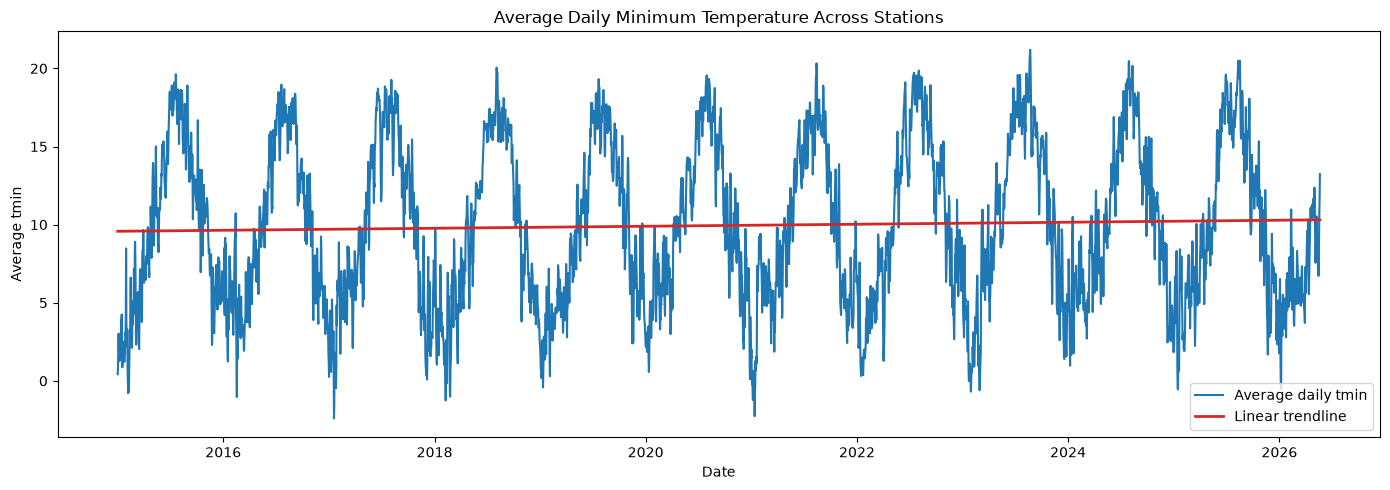

Average change per year based on the linear trendline: +0.064 °C/year


In [10]:
tmin_average = tmin_by_station.mean(axis=1)
valid_data = tmin_average.dropna()
years_elapsed = (
    valid_data.index - valid_data.index.min()
).days / 365.25

slope, intercept = np.polyfit(years_elapsed, valid_data.values, 1)
trendline = intercept + slope * years_elapsed

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    valid_data.index,
    valid_data.values,
    color="tab:blue",
    label="Average daily tmin",
)
ax.plot(
    valid_data.index,
    trendline,
    color="tab:red",
    linewidth=2,
    label="Linear trendline",
)

ax.set_title("Average Daily Minimum Temperature Across Stations")
ax.set_xlabel("Date")
ax.set_ylabel("Average tmin")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average change per year based on the linear trendline: {slope:+.3f} °C/year")

### Maps

In [17]:
master_data = pd.read_json(GEO_DATA_PATH).T.reset_index().rename(columns={"index": "idema"})
display(master_data)

,idema,ubi,lon,lat,alt
0,0009X,ALFORJA,0.963335,41.213892,406.0
1,0016A,REUS AEROPUERTO,1.163611,41.145,71.0
2,0034X,VALLS,1.260838,41.293053,233.0
3,0042Y,TARRAGONA FAC. GEOGRAFIA,1.249167,41.123892,55.0
4,0061X,PONTONS,1.519269,41.417052,632.0
...,...,...,...,...,...
817,5047E,BAZA CRUZ ROJA,-2.734995,37.505829,785.0
818,6332Y,CARBONERAS - FARO MESA ROLDÁN,-1.906944,36.942222,222.0
819,2789H,POZUELO DE TABARA,-5.909007,41.785554,711.0
820,2873X,BARBADILLO,-5.779717,40.903607,817.0


In [21]:
station_geo_data = (
    master_data[["idema", "lat", "lon", "alt"]]
    .rename(columns={"idema": "station_id"})
    .copy()
)
station_geo_data[["lat", "lon", "alt"]] = station_geo_data[["lat", "lon", "alt"]].apply(
    pd.to_numeric, errors="coerce"
)
station_geo_data.to_csv(os.path.join(CSV_DIR, "station_geo_data.csv"), index=False)
display(station_geo_data)

,station_id,lat,lon,alt
0,0009X,41.213892,0.963335,406.0
1,0016A,41.145000,1.163611,71.0
2,0034X,41.293053,1.260838,233.0
3,0042Y,41.123892,1.249167,55.0
4,0061X,41.417052,1.519269,632.0
...,...,...,...,...
817,5047E,37.505829,-2.734995,785.0
818,6332Y,36.942222,-1.906944,222.0
819,2789H,41.785554,-5.909007,711.0
820,2873X,40.903607,-5.779717,817.0
